# `Sesión 1` – Limpieza y tratamiento de datos

## Dataset: Titanic

### Objetivo de la sesión

En esta sesión se busca que el estudiante reconozca los principales problemas de calidad de datos y comprenda por qué el tratamiento de datos es un paso fundamental antes de entrenar cualquier modelo de machine learning.

Durante la práctica se trabajarán los siguientes aspectos:

- Exploración
- Valores perdidos (numéricos y categóricos)
- Valores especiales
- Datos irrelevantes o redundantes
- Errores conceptuales (clases duplicadas o mal representadas)
- Valores atípicos
- Importancia de la limpieza de datos en el desempeño de modelos de machine learning


| Columna     | Tipo       | Descripción                                           | Valores / Rango                       |
| ----------- | ---------- | ----------------------------------------------------- | ------------------------------------- |
| survived    | numérico   | Variable objetivo. Indica si el pasajero sobrevivió.  | 0 = no sobrevivió, 1 = sobrevivió     |
| pclass      | numérico   | Clase del billete — proxy del estatus socioeconómico. | 1 = primera, 2 = segunda, 3 = tercera |
| sex         | categórico | Sexo del pasajero.                                    | male, female                          |
| age         | numérico   | Edad en años. Contiene valores nulos.                 | 0.42 – 80 (con NaN)                   |
| sibsp       | numérico   | Número de hermanos o cónyuge a bordo.                 | 0 – 8                                 |
| parch       | numérico   | Número de padres o hijos a bordo.                     | 0 – 6                                 |
| fare        | numérico   | Tarifa pagada en libras esterlinas.                   | 0.0 – 512.33                          |
| embarked    | categórico | Puerto de embarque (código de letra).                 | S, C, Q                               |
| class       | categórico | Versión textual de pclass.                            | First, Second, Third                  |
| who         | categórico | Categoría según sexo y edad.                          | man, woman, child                     |
| adult_male  | booleano   | Indica si el pasajero es un hombre adulto.            | True, False                           |
| deck        | categórico | Cubierta del camarote. Alta tasa de nulos.            | A–G (con NaN)                         |
| embark_town | categórico | Nombre completo del puerto de embarque.               | Southampton, Cherbourg, Queenstown    |
| alive       | categórico | Versión textual de survived.                          | yes, no                               |
| alone       | booleano   | True si viajaba sin familia.                          | True, False                           |


### Carga del dataset

Trabajaremos con el dataset Titanic en un solo archivo, lo que representa un escenario más cercano a un proyecto real de machine learning, donde primero se reciben los datos completos y luego se procesan.

Usaremos el dataset presente en:
"https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv"


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

# Cargar el dataset desde data/raw/ (con fallback a la URL si no existe localmente)
DATA_PATH = Path.cwd().parent / "data" / "raw" / "titanic.csv"
URL = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv"

if DATA_PATH.exists():
    df = pd.read_csv(DATA_PATH)
    print(f"Cargado desde local: {DATA_PATH}")
else:
    df = pd.read_csv(URL)
    print(f"Cargado desde URL: {URL}")

df.head(12)


Matplotlib is building the font cache; this may take a moment.


Cargado desde local: /Users/noovou/dev/fup/estadistica/data/raw/titanic.csv


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
5,0,3,male,NaN,0,0,8.4583,Q,Third,man,True,NaN,Queenstown,no,True
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
7,0,3,male,2.0,3,1,21.0750,S,Third,child,False,NaN,Southampton,no,False
8,1,3,female,27.0,0,2,11.1333,S,Third,woman,False,NaN,Southampton,yes,False
9,1,2,female,14.0,1,0,30.0708,C,Second,child,False,NaN,Cherbourg,yes,False


In [2]:
dimensiones = df.shape

print(dimensiones)

(891, 15)


Exploración inicial del dataset de manera Gráfica


In [3]:
cat_vars = ["sex", "embarked", "class", "who", "deck", "embark_town", "alive"]

print("Resumen de variables categóricas:")
print(f"{'Variable':<15} {'Categorías únicas':>18} {'NAs':>6}")
print("-" * 42)
for v in cat_vars:
    print(f"{v:<15} {df[v].nunique():>18} {df[v].isna().sum():>6}")

Resumen de variables categóricas:
Variable         Categorías únicas    NAs
------------------------------------------
sex                              2      0
embarked                         3      2
class                            3      0
who                              3      0
deck                             7    688
embark_town                      3      2
alive                            2      0


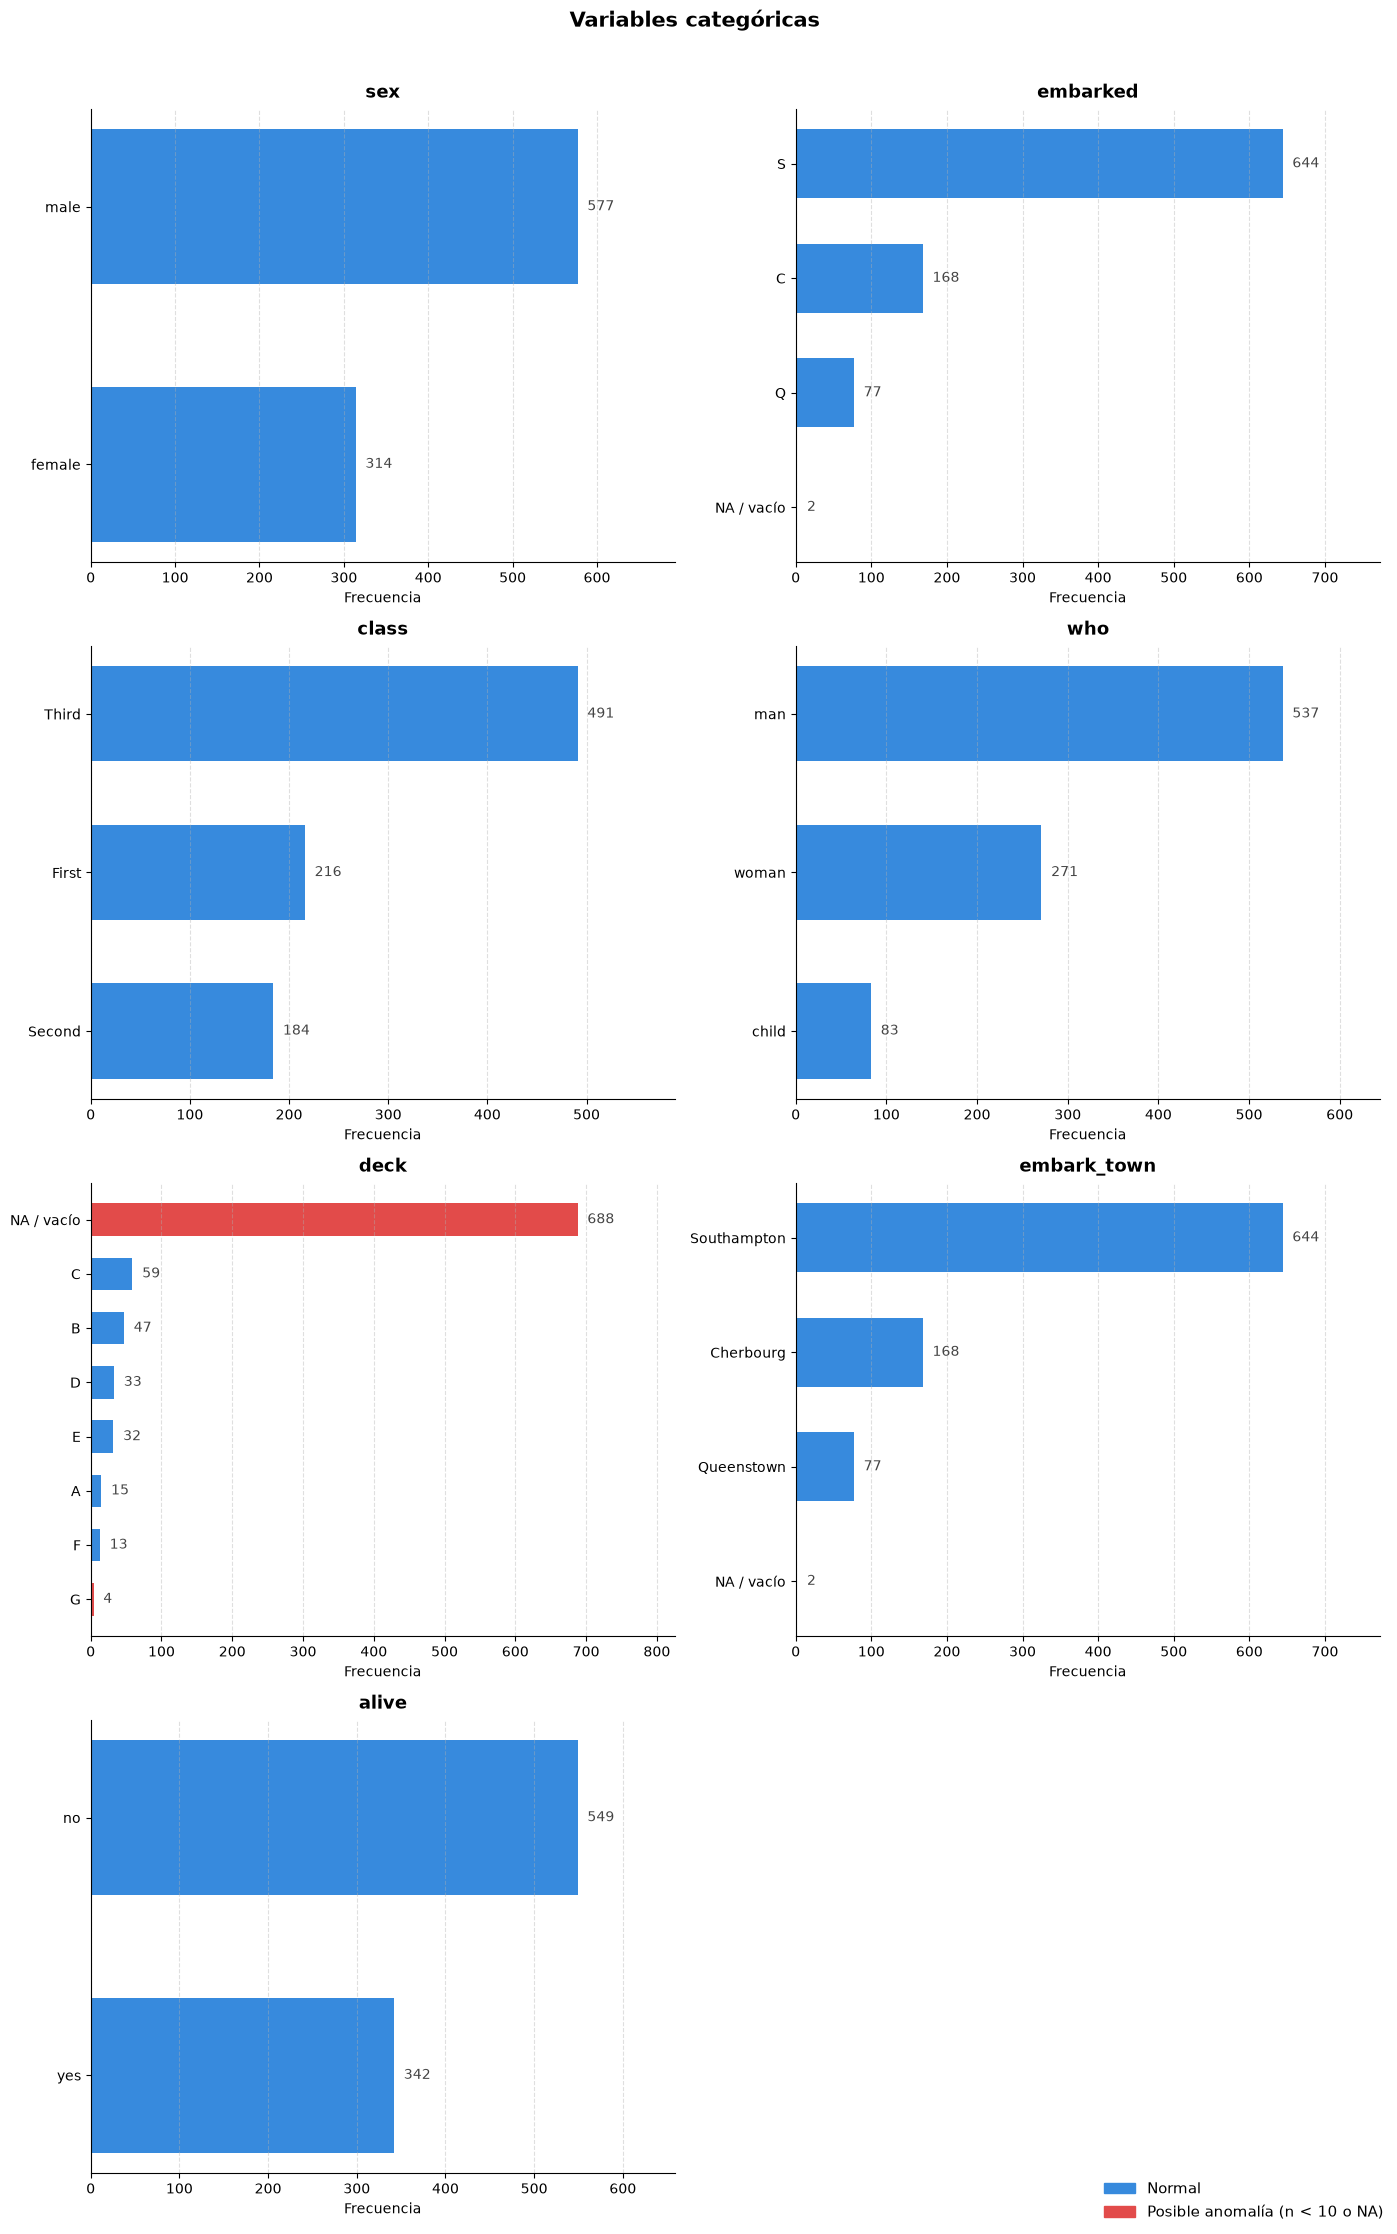

In [ ]:
fig, axes = plt.subplots(4, 2, figsize=(14, 22))
axes = axes.flatten()
for i, var in enumerate(cat_vars):
    ax = axes[i]

    conteo = df[var].fillna("NA / vacío").value_counts().sort_values()
    colores = [
        "#E24B4A" if (v == "NA / vacío" or conteo[v] < 10) else "#378ADD" for v in conteo.index
    ]

    bars = ax.barh(
        conteo.index.astype(str), conteo.values, color=colores, height=0.6, edgecolor="none"
    )

    for bar, val in zip(bars, conteo.values):
        ax.text(
            bar.get_width() + conteo.max() * 0.02,
            bar.get_y() + bar.get_height() / 2,
            str(val),
            va="center",
            ha="left",
            fontsize=10,
            color="#444",
        )

    ax.set_title(var, fontsize=13, fontweight="bold", pad=8)
    ax.set_xlabel("Frecuencia", fontsize=10)
    ax.set_xlim(0, conteo.max() * 1.2)
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(axis="y", labelsize=10)
    ax.grid(axis="x", linestyle="--", alpha=0.4)

# Nota:
axes[-1].set_visible(False)


parche_normal = mpatches.Patch(color="#378ADD", label="Normal")
parche_anomalia = mpatches.Patch(color="#E24B4A", label="Posible anomalía (n < 10 o NA)")
fig.legend(handles=[parche_normal, parche_anomalia], loc="lower right", fontsize=11, frameon=False)

fig.suptitle("Variables categóricas", fontsize=15, fontweight="bold", y=1.01)

plt.tight_layout()
plt.show()

Resumen de variables numéricas (método IQR):
Variable         Q1       Q3      IQR   Lim. inf   Lim. sup   Outliers
------------------------------------------------------------
age           20.12    38.00    17.88      -6.69      64.81         11
sibsp          0.00     1.00     1.00      -1.50       2.50         46
parch          0.00     0.00     0.00       0.00       0.00        213
fare           7.91    31.00    23.09     -26.72      65.63        116


/var/folders/8q/0h00n1_j1tg40d1vdfzf0db40000gn/T/ipykernel_1896/3272609717.py:24: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  bp = ax.boxplot(data, vert=False, patch_artist=True, widths=0.5,
/var/folders/8q/0h00n1_j1tg40d1vdfzf0db40000gn/T/ipykernel_1896/3272609717.py:24: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  bp = ax.boxplot(data, vert=False, patch_artist=True, widths=0.5,
/var/folders/8q/0h00n1_j1tg40d1vdfzf0db40000gn/T/ipykernel_1896/3272609717.py:24: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  bp = ax.boxplot(data, vert=False, patch_artist=True, widths=0.5,
/var/folders/8q/0h00n1_j1tg40d1vdfzf0db40000gn/T/ipykernel_1896/3272609717.py:24: 

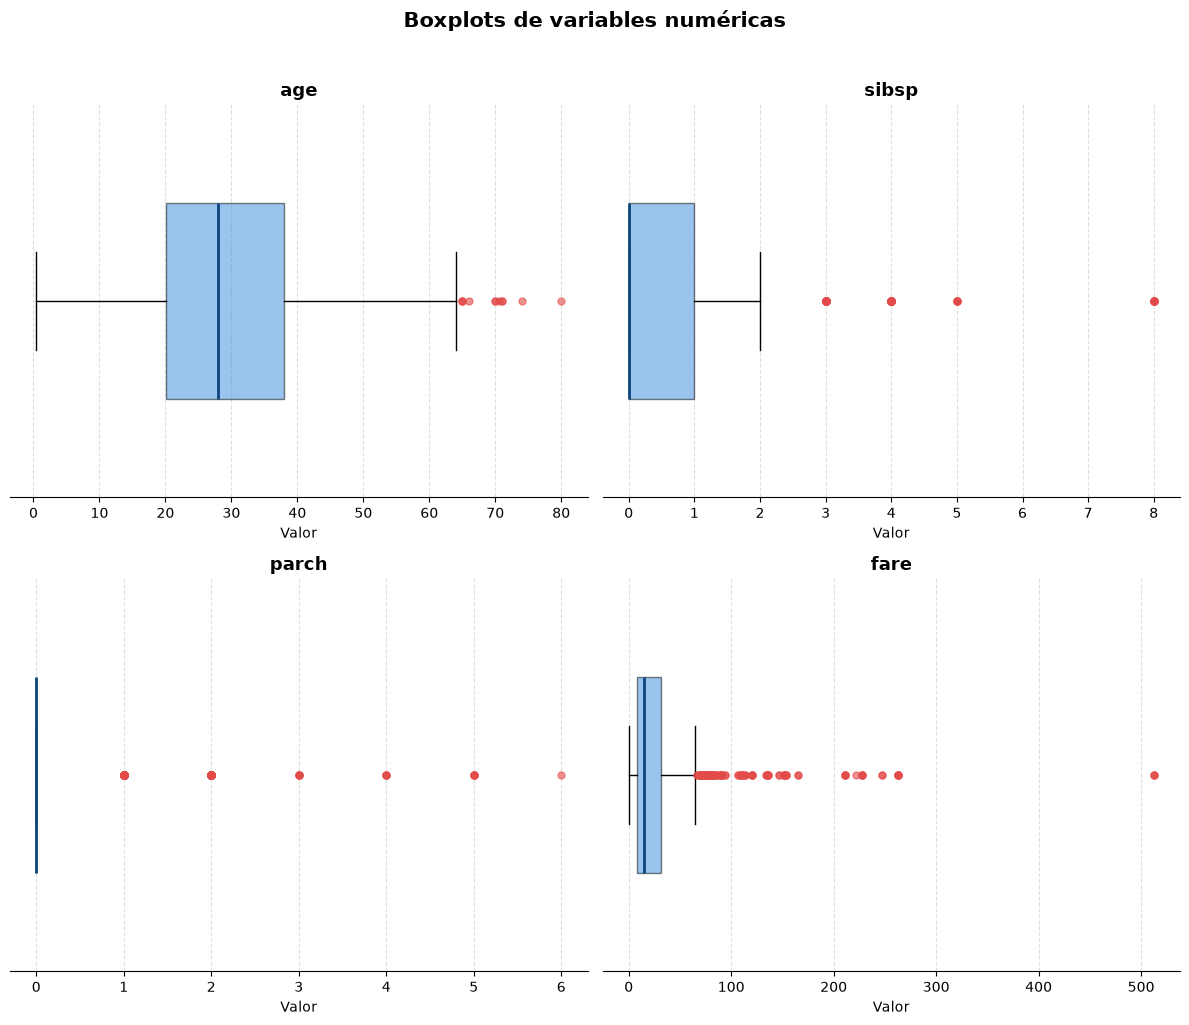

In [ ]:
num_vars = ["age", "sibsp", "parch", "fare"]

# Resumen estadístico y detección de outliers vía IQR
print("Resumen de variables numéricas (método IQR):")
print(
    f"{'Variable':<10} {'Q1':>8} {'Q3':>8} {'IQR':>8} {'Lim. inf':>10} {'Lim. sup':>10} {'Outliers':>10}"
)
print("-" * 60)
for var in num_vars:
    q1 = df[var].quantile(0.25)
    q3 = df[var].quantile(0.75)
    iqr = q3 - q1
    lim_inf = q1 - 1.5 * iqr
    lim_sup = q3 + 1.5 * iqr
    n_outliers = ((df[var] < lim_inf) | (df[var] > lim_sup)).sum()
    print(
        f"{var:<10} {q1:>8.2f} {q3:>8.2f} {iqr:>8.2f} {lim_inf:>10.2f} {lim_sup:>10.2f} {n_outliers:>10}"
    )

# Graficar boxplots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, var in enumerate(num_vars):
    ax = axes[i]
    data = df[var].dropna()

    bp = ax.boxplot(
        data,
        vert=False,
        patch_artist=True,
        widths=0.5,
        flierprops=dict(
            marker="o",
            markerfacecolor="#E24B4A",
            markeredgecolor="#E24B4A",
            markersize=5,
            alpha=0.6,
        ),
    )

    bp["boxes"][0].set_facecolor("#378ADD")
    bp["boxes"][0].set_alpha(0.5)
    bp["medians"][0].set_color("#0C447C")
    bp["medians"][0].set_linewidth(2)

    ax.set_title(var, fontsize=13, fontweight="bold")
    ax.set_yticks([])
    ax.set_xlabel("Valor")
    ax.spines[["top", "right", "left"]].set_visible(False)
    ax.grid(axis="x", linestyle="--", alpha=0.4)

fig.suptitle("Boxplots de variables numéricas", fontsize=15, fontweight="bold", y=1.02)

plt.tight_layout()
plt.show()

### Exploración inicial del dataset

Antes de limpiar los datos, es fundamental explorar el dataset para entender:

- Qué variables existen
- Qué tipo de datos contiene cada columna
- Si hay valores faltantes


In [6]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    str    
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    str    
 8   class        891 non-null    str    
 9   who          891 non-null    str    
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    str    
 12  embark_town  889 non-null    str    
 13  alive        891 non-null    str    
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), str(7)
memory usage: 92.4 KB


In [7]:
df.describe(include="all")

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
count,891.000000,891.000000,891,714.000000,891.000000,891.000000,891.000000,889,891,891,891,203,889,891,891
unique,NaN,NaN,2,NaN,NaN,NaN,NaN,3,3,3,2,7,3,2,2
top,NaN,NaN,male,NaN,NaN,NaN,NaN,S,Third,man,True,C,Southampton,no,True
freq,NaN,NaN,577,NaN,NaN,NaN,NaN,644,491,537,537,59,644,549,537
mean,0.383838,2.308642,NaN,29.699118,0.523008,0.381594,32.204208,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,0.486592,0.836071,NaN,14.526497,1.102743,0.806057,49.693429,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,0.000000,1.000000,NaN,0.420000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,0.000000,2.000000,NaN,20.125000,0.000000,0.000000,7.910400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,0.000000,3.000000,NaN,28.000000,0.000000,0.000000,14.454200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,1.000000,3.000000,NaN,38.000000,1.000000,0.000000,31.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Identificación de valores perdidos

Los valores perdidos son uno de los problemas más comunes en los datasets reales.
Un modelo de machine learning no puede trabajar directamente con valores nulos, por lo que deben ser tratados.

En este paso identificaremos valores faltantes tanto en variables numéricas como categóricas.


In [8]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

### Tratamiento de valores faltantes numéricos

La variable `age` es numérica y contiene valores faltantes.
Una estrategia común es reemplazar estos valores por la media o la mediana.

En este caso se utilizará la mediana, ya que es menos sensible a valores extremos.


In [9]:
df["age"] = df["age"].fillna(df["age"].median())


### Tratamiento de valores faltantes categóricos

Las variables categóricas requieren un tratamiento diferente a las numéricas.

- Si una variable tiene pocos valores faltantes, se puede imputar con la moda.
- Si una variable tiene demasiados valores faltantes, puede ser más conveniente eliminarla.

En este dataset:

- `embarked` se imputará con la moda.
- `deck` será eliminada debido a la gran cantidad de valores faltantes.


In [10]:
df["embarked"] = df["embarked"].fillna(df["embarked"].mode()[0])
df = df.drop(columns=["deck"])


### Datos irrelevantes o redundantes

No todas las variables aportan información útil para el modelo.
Algunas columnas contienen información duplicada o redundante.

Ejemplos:

- `alive` duplica la información de `survived`
- `class` duplica `pclass`
- `embark_town` duplica `embarked`

Estas variables serán eliminadas.


In [11]:
df = df.drop(columns=["alive", "class", "embark_town"])


### Variables derivadas y consideraciones conceptuales

Algunas variables del dataset han sido creadas a partir de otras, como:

- `adult_male`
- `who`
- `alone`

Estas variables pueden introducir redundancia o fuga de información.
Para esta sesión introductoria, se eliminarán para simplificar el análisis.


In [12]:
df = df.drop(columns=["adult_male", "who", "alone"])


### Valores atípicos (outliers)

Los valores atípicos pueden afectar el desempeño de muchos algoritmos de machine learning.
En la variable `fare` se observan valores extremadamente altos.

En este punto se analiza su distribución y se discuten posibles tratamientos.


In [ ]:
df["fare"].describe()


count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: fare, dtype: float64

<Axes: >

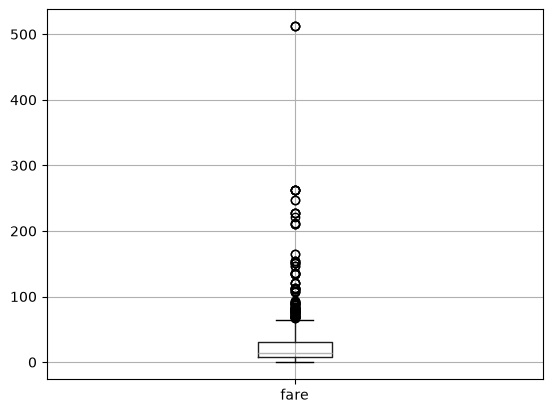

In [ ]:
df.boxplot(column="fare")


### Revisión final del dataset

Después del proceso de limpieza, se revisa nuevamente el dataset para verificar:

- Que no existan valores faltantes
- Que las variables sean coherentes
- Que los datos estén listos para el modelado


In [15]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  891 non-null    int64  
 1   pclass    891 non-null    int64  
 2   sex       891 non-null    str    
 3   age       891 non-null    float64
 4   sibsp     891 non-null    int64  
 5   parch     891 non-null    int64  
 6   fare      891 non-null    float64
 7   embarked  891 non-null    str    
dtypes: float64(2), int64(4), str(2)
memory usage: 55.8 KB


In [16]:
df.isnull().sum()


survived    0
pclass      0
sex         0
age         0
sibsp       0
parch       0
fare        0
embarked    0
dtype: int64

### Conclusión de la sesión

El tratamiento de datos no es un paso opcional en machine learning.
La calidad del modelo depende directamente de la calidad de los datos utilizados.

Un modelo aprende exactamente a partir de los datos que recibe.
Datos con errores, valores faltantes o ruido generan modelos poco confiables.
